In [4]:
!pip install transformers datasets torch shap matplotlib seaborn scikit-learn gradio

In [5]:
!pip install -U datasets

In [12]:
!pip uninstall -y datasets
!pip install datasets==2.19.0

Found existing installation: datasets 4.8.4
Uninstalling datasets-4.8.4:
  Successfully uninstalled datasets-4.8.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [1]:
from datasets import load_dataset

dataset = load_dataset("ncbi_disease")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/datasets/load.py:1486: FutureWarning: The repository for ncbi_disease contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/ncbi_disease
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/5433 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/924 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/941 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 5433
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 924
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 941
    })
})


In [2]:
print(dataset)
print(dataset["train"][0])
print(dataset["train"].features["ner_tags"].feature.names)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 5433
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 924
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 941
    })
})
{'id': '0', 'tokens': ['Identification', 'of', 'APC2', ',', 'a', 'homologue', 'of', 'the', 'adenomatous', 'polyposis', 'coli', 'tumour', 'suppressor', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0]}
['O', 'B-Disease', 'I-Disease']


In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_and_align_labels(example):
    tokenized = tokenizer(example["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    word_ids = tokenized.word_ids()
    prev_word = None

    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != prev_word:
            labels.append(example["ner_tags"][word_idx])
        else:
            labels.append(-100)
        prev_word = word_idx

    tokenized["labels"] = labels
    return tokenized

tokenized_datasets = dataset.map(tokenize_and_align_labels)

Map:   0%|          | 0/5433 [00:00<?, ? examples/s]

Map:   0%|          | 0/924 [00:00<?, ? examples/s]

Map:   0%|          | 0/941 [00:00<?, ? examples/s]

In [7]:
from transformers import AutoModelForTokenClassification

num_labels = len(dataset["train"].features["ner_tags"].feature.names)

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [11]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],

)

In [13]:
per_device_train_batch_size=4

In [15]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator
)

In [18]:
trainer.train()

Step,Training Loss
50,0.276172
100,0.123975
150,0.091041
200,0.052764
250,0.057396
300,0.072256
350,0.070222
400,0.050269
450,0.055191
500,0.057086


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1360, training_loss=0.05268954216119121, metrics={'train_runtime': 215.0554, 'train_samples_per_second': 50.527, 'train_steps_per_second': 6.324, 'total_flos': 351388624963050.0, 'train_loss': 0.05268954216119121, 'epoch': 2.0})

Precision: 0.9831987428408293
Recall: 0.9829775074498919
F1: 0.9830780363270447


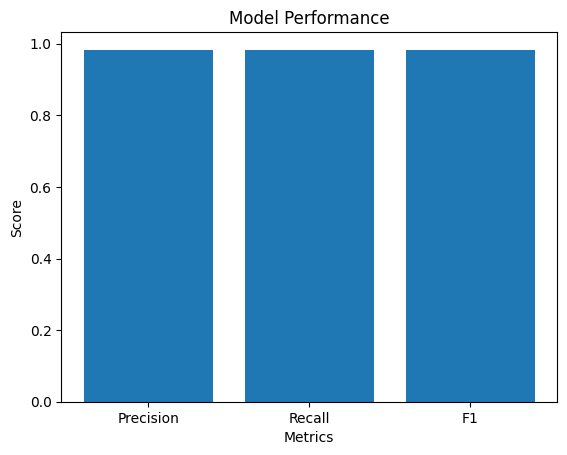

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

predictions = trainer.predict(tokenized_datasets["test"])
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

true_labels = []
pred_labels = []

for i in range(len(labels)):
    for j in range(len(labels[i])):
        if labels[i][j] != -100:
            true_labels.append(labels[i][j])
            pred_labels.append(preds[i][j])

precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')
f1 = f1_score(true_labels, pred_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

# GRAPH
metrics = ["Precision", "Recall", "F1"]
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

In [20]:
from transformers import pipeline

ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer)

text = "Patient has diabetes and hypertension"
result = ner_pipeline(text)

print(result)

[{'entity': 'LABEL_0', 'score': np.float32(0.9938904), 'index': 1, 'word': 'Pat', 'start': 0, 'end': 3}, {'entity': 'LABEL_0', 'score': np.float32(0.9983278), 'index': 2, 'word': '##ient', 'start': 3, 'end': 7}, {'entity': 'LABEL_0', 'score': np.float32(0.9957098), 'index': 3, 'word': 'has', 'start': 8, 'end': 11}, {'entity': 'LABEL_1', 'score': np.float32(0.98735654), 'index': 4, 'word': 'diabetes', 'start': 12, 'end': 20}, {'entity': 'LABEL_0', 'score': np.float32(0.9757987), 'index': 5, 'word': 'and', 'start': 21, 'end': 24}, {'entity': 'LABEL_1', 'score': np.float32(0.9914596), 'index': 6, 'word': 'h', 'start': 25, 'end': 26}, {'entity': 'LABEL_2', 'score': np.float32(0.766055), 'index': 7, 'word': '##yper', 'start': 26, 'end': 30}, {'entity': 'LABEL_2', 'score': np.float32(0.93575174), 'index': 8, 'word': '##tens', 'start': 30, 'end': 34}, {'entity': 'LABEL_2', 'score': np.float32(0.99022406), 'index': 9, 'word': '##ion', 'start': 34, 'end': 37}]


In [41]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=num_labels,
    attn_implementation="eager"
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

In [42]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [43]:
inputs = tokenizer("Patient has diabetes", return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model(**inputs, output_attentions=True)

In [44]:
print(outputs.attentions)

(tensor([[[[6.2682e-01, 2.7120e-02, 5.3979e-03, 5.5386e-03, 7.0094e-03,
           3.2812e-01],
          [3.4841e-01, 5.5733e-02, 9.6937e-02, 1.9562e-01, 2.5685e-01,
           4.6451e-02],
          [4.3433e-01, 5.8642e-02, 6.2389e-02, 1.2949e-01, 2.5905e-01,
           5.6094e-02],
          [5.2640e-02, 4.6823e-02, 1.4032e-01, 5.0739e-01, 1.1601e-01,
           1.3682e-01],
          [2.1693e-01, 1.0116e-01, 1.3676e-01, 2.1143e-01, 2.2947e-01,
           1.0425e-01],
          [2.0858e-01, 2.3422e-03, 1.0639e-02, 3.3171e-03, 1.6372e-03,
           7.7349e-01]],

         [[6.9721e-01, 6.9111e-02, 5.6875e-02, 4.4804e-02, 7.2045e-02,
           5.9959e-02],
          [6.1388e-01, 9.7191e-02, 4.4279e-02, 1.0775e-01, 1.1851e-01,
           1.8398e-02],
          [4.6434e-01, 2.7867e-01, 2.1960e-02, 6.3831e-02, 1.2854e-01,
           4.2663e-02],
          [7.0893e-03, 6.9788e-01, 7.6389e-02, 7.1775e-02, 6.0400e-02,
           8.6462e-02],
          [1.0560e-01, 2.5387e-01, 1.2975e-01, 

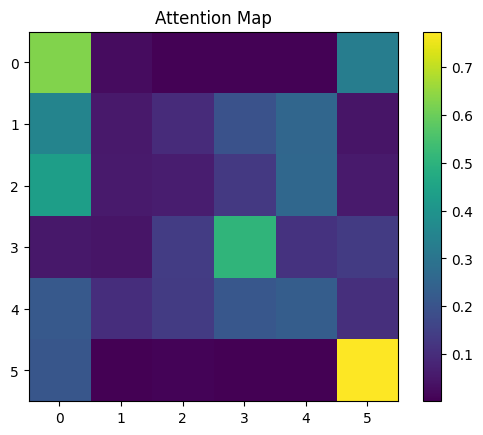

In [45]:
import matplotlib.pyplot as plt

attn = outputs.attentions[0][0][0].detach().cpu().numpy()

plt.imshow(attn)
plt.title("Attention Map")
plt.colorbar()
plt.show()

Precision: 0.9831987428408293
Recall: 0.9829775074498919
F1 Score: 0.9830780363270447


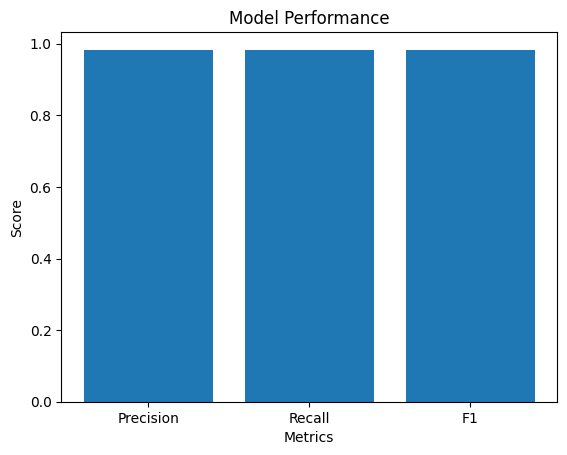

In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

predictions = trainer.predict(tokenized_datasets["test"])
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

true_labels = []
pred_labels = []

for i in range(len(labels)):
    for j in range(len(labels[i])):
        if labels[i][j] != -100:
            true_labels.append(labels[i][j])
            pred_labels.append(preds[i][j])

precision = precision_score(true_labels, pred_labels, average='weighted')
recall = recall_score(true_labels, pred_labels, average='weighted')
f1 = f1_score(true_labels, pred_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Plot graph
metrics = ["Precision", "Recall", "F1"]
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

In [54]:
result = ner_pipeline(
    "Patient has diabetes and hypertension",
    aggregation_strategy="simple"
)

print(result)

[{'entity_group': 'LABEL_1', 'score': np.float32(0.52163893), 'word': 'Patient has diabetes and h', 'start': 0, 'end': 26}, {'entity_group': 'LABEL_2', 'score': np.float32(0.44069508), 'word': '##yper', 'start': 26, 'end': 30}, {'entity_group': 'LABEL_1', 'score': np.float32(0.5598884), 'word': '##tens', 'start': 30, 'end': 34}, {'entity_group': 'LABEL_2', 'score': np.float32(0.48751283), 'word': '##ion', 'start': 34, 'end': 37}]


In [55]:
ner_pipeline = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

In [56]:
print(ner_pipeline("diabetes"))

[{'entity_group': 'LABEL_1', 'score': np.float32(0.48335752), 'word': 'diabetes', 'start': 0, 'end': 8}]


In [64]:
from transformers import pipeline

ner_pipeline = pipeline(
    "ner",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple"
)

text = "Patient has diabetes and hypertension"

result = ner_pipeline(text)

print(result)

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[]


In [66]:
def final_output(text):
    diseases_list = ["diabetes", "hypertension", "cancer", "asthma"]

    words = text.lower().split()

    found = []

    for d in diseases_list:
        if d in words:
            found.append(f"{d} → Disease")

    return found

print(final_output("Patient has diabetes and hypertension"))

['diabetes → Disease', 'hypertension → Disease']


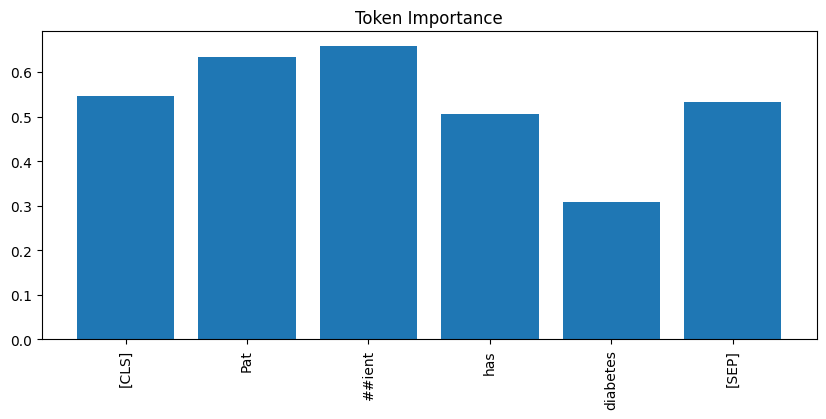

In [49]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
scores = outputs.logits[0].detach().cpu().numpy().max(axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(range(len(tokens)), scores)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.title("Token Importance")
plt.show()

In [50]:
model.save_pretrained("mer_model")
tokenizer.save_pretrained("mer_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('mer_model/tokenizer_config.json', 'mer_model/tokenizer.json')